In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [4]:
df = pd.read_csv("E:/Tugas Anthar/PROJECT/Sales Performance Dashboard for E-commerce Retail/Data/clean/data_clean.csv")

# EDA

In [5]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

date_col = pick_col(df, ['order_date', 'Order Date'])
order_id_col = pick_col(df, ['order_id', 'Order ID'])
sales_col = pick_col(df, ['Sales', 'sales'])
profit_col = pick_col(df, ['Profit', 'profit'])
discount_col = pick_col(df, ['Discount', 'discount'])
quantity_col = pick_col(df, ['Quantity', 'quantity'])
person_col = pick_col(df, ['Person', 'person'])
segment_col = pick_col(df, ['Segment', 'segment'])
region_col = pick_col(df, ['Region', 'region'])
state_col = pick_col(df, ['State', 'state'])
category_col = pick_col(df, ['Category', 'category'])
subcat_col = pick_col(df, ['sub_category', 'Sub-Category', 'subCategory'])
product_col = pick_col(df, ['product_name', 'Product Name'])
customer_col = pick_col(df, ['customer_id', 'Customer ID'])
returned_col = pick_col(df, ['Returned', 'returned'])
ship_mode_col = pick_col(df, ['ship_mode', 'Ship Mode'])
ship_days_col = pick_col(df, ['ship_days', 'Ship Days'])

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['year'] = df[date_col].dt.year
df['month'] = df[date_col].dt.month
df['month_name'] = df[date_col].dt.strftime('%b')
df['quarter'] = 'Q' + df[date_col].dt.quarter.astype(str)

if returned_col is not None:
    df['_returned_flag'] = (
        df[returned_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(['yes', 'true', '1', 'returned'])
        .astype(int)
    )
else:
    df['_returned_flag'] = 0

## Yearly KPI

In [6]:
yearly_kpi = (
    df.groupby('year', as_index=False)
      .agg(
          sales=(sales_col, 'sum'),
          profit=(profit_col, 'sum'),
          orders=(order_id_col, 'nunique'),
          discount=(discount_col, 'mean'),
          quantity=(quantity_col,sum)
      )
)

yearly_kpi['margin_pct'] = (yearly_kpi['profit'] / yearly_kpi['sales']) * 100
yearly_kpi['aov'] = yearly_kpi['sales'] / yearly_kpi['orders']

yearly_kpi['sales_growth_pct'] = yearly_kpi['sales'].pct_change() * 100
yearly_kpi['profit_growth_pct'] = yearly_kpi['profit'].pct_change() * 100
yearly_kpi['orders_growth_pct'] = yearly_kpi['orders'].pct_change() * 100
yearly_kpi['discount_growth_pct'] = yearly_kpi['discount'].pct_change() * 100

cols_to_round = [
    'sales', 'profit', 'margin_pct', 'aov', 'discount',
    'sales_growth_pct', 'profit_growth_pct', 'orders_growth_pct', 'discount_growth_pct'
]
yearly_kpi[cols_to_round] = yearly_kpi[cols_to_round].round(2)

yearly_kpi

C:\Users\anthar\AppData\Local\Temp\ipykernel_22748\1286890981.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg(


,year,sales,profit,orders,discount,quantity,margin_pct,aov,sales_growth_pct,profit_growth_pct,orders_growth_pct,discount_growth_pct
0,2018,484247.50,49543.97,969,0.16,7581,10.23,499.74,NaN,NaN,NaN,NaN
1,2019,470532.51,61618.60,1038,0.16,7979,13.10,453.31,-2.83,24.37,7.12,-1.69
2,2020,609205.60,81795.17,1315,0.15,9837,13.43,463.27,29.47,32.74,26.69,-0.56
3,2021,733215.26,93439.27,1687,0.16,12476,12.74,434.63,20.36,14.24,28.29,1.11


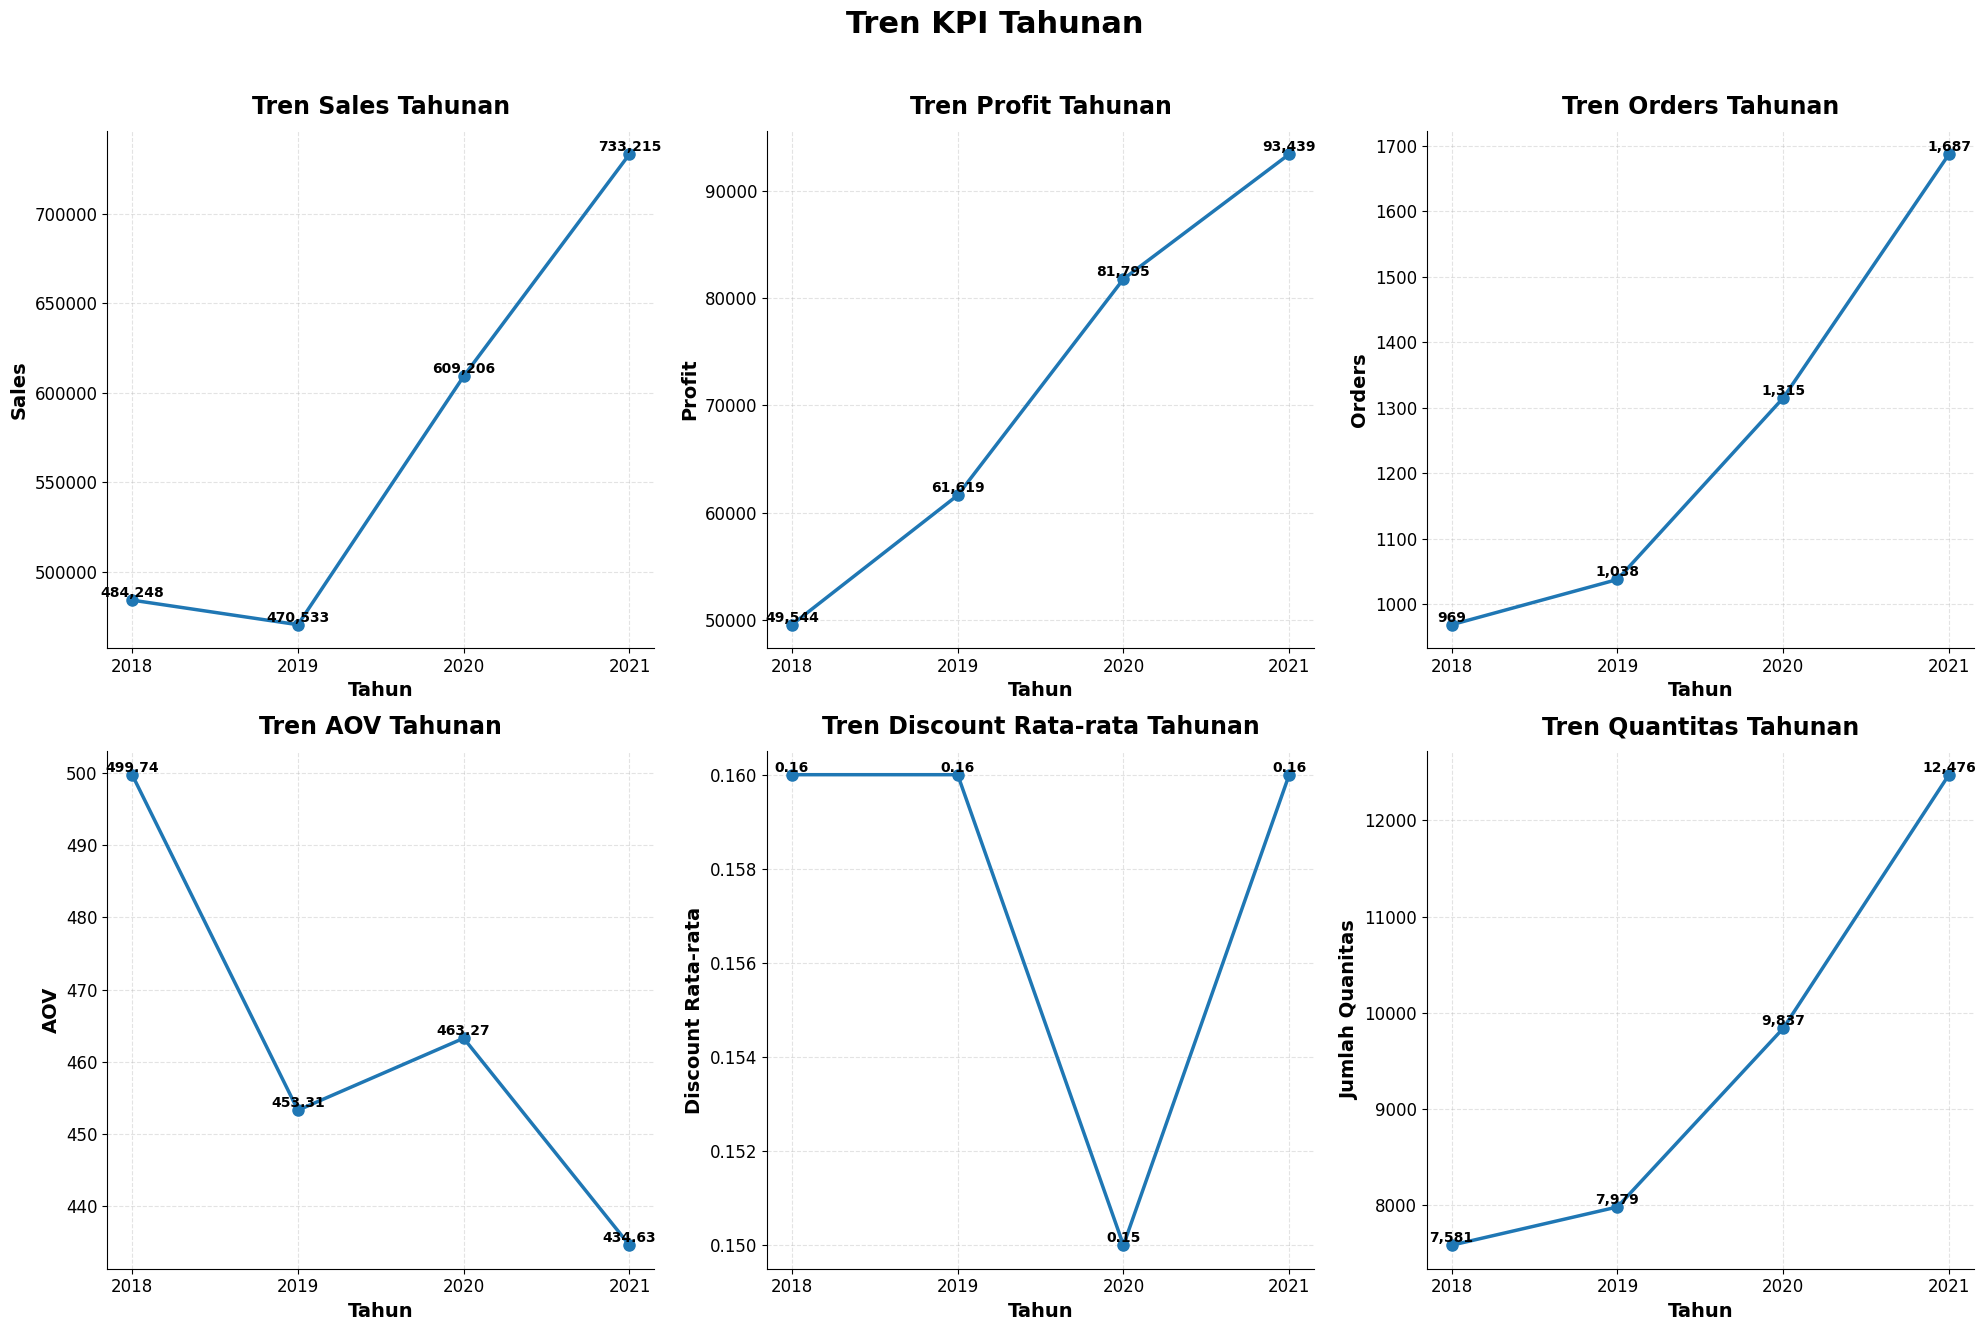

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

charts = [
    ('sales', 'Tren Sales Tahunan', 'Sales'),
    ('profit', 'Tren Profit Tahunan', 'Profit'),
    ('orders', 'Tren Orders Tahunan', 'Orders'),
    ('aov', 'Tren AOV Tahunan', 'AOV'),
    ('discount', 'Tren Discount Rata-rata Tahunan', 'Discount Rata-rata'),
    ('quantity','Tren Quantitas Tahunan', 'Jumlah Quanitas')
]

for i, (col, title, ylabel) in enumerate(charts):
    ax = axes[i]

    ax.plot(
        yearly_kpi['year'],
        yearly_kpi[col],
        marker='o',
        linewidth=2.5,
        markersize=8
    )

    ax.set_title(title, fontsize=17, fontweight='bold', pad=12)
    ax.set_xlabel('Tahun', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_xticks(yearly_kpi['year'])
    ax.tick_params(axis='both', labelsize=12)

    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # label nilai di tiap titik
    for x, y in zip(yearly_kpi['year'], yearly_kpi[col]):
        if col in ['discount']:
            label = f'{y:.2f}'
        elif col in ['aov']:
            label = f'{y:,.2f}'
        else:
            label = f'{y:,.0f}'

        ax.text(
            x, y, label,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# sembunyikan subplot kosong
for j in range(len(charts), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tren KPI Tahunan', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

📈 Insight Tren Kinerja 2018–2021

📆 2018–2019: Order Naik, tapi Nilai Transaksi Melemah
Pada periode **2018–2019**, jumlah **orders** dan **quantity** masih mengalami kenaikan 📦, tetapi **sales justru turun** 📉.

Hal ini mengindikasikan bahwa pertumbuhan transaksi belum diikuti oleh kenaikan nilai penjualan. Penurunan **AOV** dari **499,74** menjadi **453,31** juga memperkuat bahwa rata-rata nilai belanja per transaksi kecil.

💡 Interpretasi:
- 🛒 transaksi bertambah, tetapi nilai belanjanya lebih rendah
- 📦 basket size cenderung mengecil
- 💰 pelanggan kemungkinan membeli produk dengan harga lebih murah

Menariknya, **profit tetap naik** pada periode ini 📈, yang menunjukkan bahwa bisnis masih mampu menjaga profitabilitas meskipun nilai transaksi rata-rata menurun.

---

📆 2020: Awal Pertumbuhan yang Lebih Sehat
Tahun **2020** menjadi titik balik yang sangat positif 🌟.  
Pada tahun ini, **sales, profit, orders, quantity, dan AOV** semuanya meningkat secara bersamaan.

Ini menunjukkan bahwa pertumbuhan tidak hanya datang dari **lebih banyak transaksi**, tetapi juga dari **nilai transaksi yang ikut membesar** 💵. Dengan kata lain, performa bisnis tumbuh lebih seimbang dan lebih berkualitas.

✨ Sorotan utama:
- 📈 **Sales naik signifikan**
- 💸 **Profit ikut meningkat**
- 🛍️ **AOV naik**, artinya nilai rata-rata per order membaik
- 🎯 **Discount rata-rata turun ke 0,15**, sehingga pertumbuhan terlihat lebih sehat karena tidak terlalu bergantung pada promosi

👉 Tahun 2020 bisa dibilang sebagai fase **pertumbuhan paling sehat** dalam periode ini.

---

📆 2021: Tumbuh Kuat, tapi Lebih Ditopang Volume
Pada **2021**, performa bisnis kembali mencatat pertumbuhan yang sangat kuat 🚀.  
**Sales, profit, orders, dan quantity** semuanya naik ke level tertinggi selama periode pengamatan.

Namun, ada satu sinyal penting yang perlu diperhatikan 👀:  
**AOV justru turun** dari **463,27** menjadi **434,63**.

Artinya, walaupun bisnis terus tumbuh, pertumbuhan tersebut lebih banyak didorong oleh **kenaikan volume penjualan** daripada kenaikan nilai rata-rata per transaksi.

💡 Interpretasi:
- 📦 lebih banyak barang terjual
- 🧾 jumlah order meningkat pesat
- 💰 tetapi nilai rata-rata tiap transaksi menurun
- 🏷️ discount rata-rata kembali naik ke **0,16**, yang bisa menandakan pertumbuhan mulai lebih bergantung pada promosi

👉 Jadi, **profit 2021 lebih banyak ditopang oleh skala penjualan**, bukan oleh ticket size yang lebih besar.

## Quarterly KPI

In [8]:
quarterly_kpi = (
    df.groupby(['year', 'quarter'], as_index=False)
      .agg(
          sales=(sales_col, 'sum'),
          profit=(profit_col, 'sum'),
          orders=(order_id_col, 'nunique'),
          quantity=(quantity_col, 'sum'),
          discount=(discount_col, 'mean')
      )
)

quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
quarterly_kpi['quarter_order'] = quarterly_kpi['quarter'].map(quarter_order)
quarterly_kpi = quarterly_kpi.sort_values(['year', 'quarter_order']).drop(columns='quarter_order')

quarterly_kpi['margin_pct'] = (quarterly_kpi['profit'] / quarterly_kpi['sales']) * 100
quarterly_kpi['aov'] = quarterly_kpi['sales'] / quarterly_kpi['orders']

cols_to_round = ['sales', 'profit', 'discount', 'margin_pct', 'aov']
quarterly_kpi[cols_to_round] = quarterly_kpi[cols_to_round].round(2)

quarterly_kpi

,year,quarter,sales,profit,orders,quantity,discount,margin_pct,aov
0,2018,Q1,74447.80,3811.23,131,1028,0.16,5.12,568.30
1,2018,Q2,86538.76,11204.07,201,1523,0.15,12.95,430.54
2,2018,Q3,143633.21,12804.72,267,2159,0.16,8.91,537.95
3,2018,Q4,179627.73,21723.95,370,2871,0.17,12.09,485.48
4,2019,Q1,68851.74,9264.94,144,990,0.15,13.46,478.14
5,2019,Q2,89124.19,12190.92,214,1604,0.17,13.68,416.47
6,2019,Q3,130259.58,16853.62,274,2241,0.15,12.94,475.40
7,2019,Q4,182297.01,23309.12,406,3144,0.15,12.79,449.01
8,2020,Q1,93237.18,11441.37,179,1243,0.15,12.27,520.88
9,2020,Q2,136082.30,16390.34,294,2240,0.16,12.04,462.86


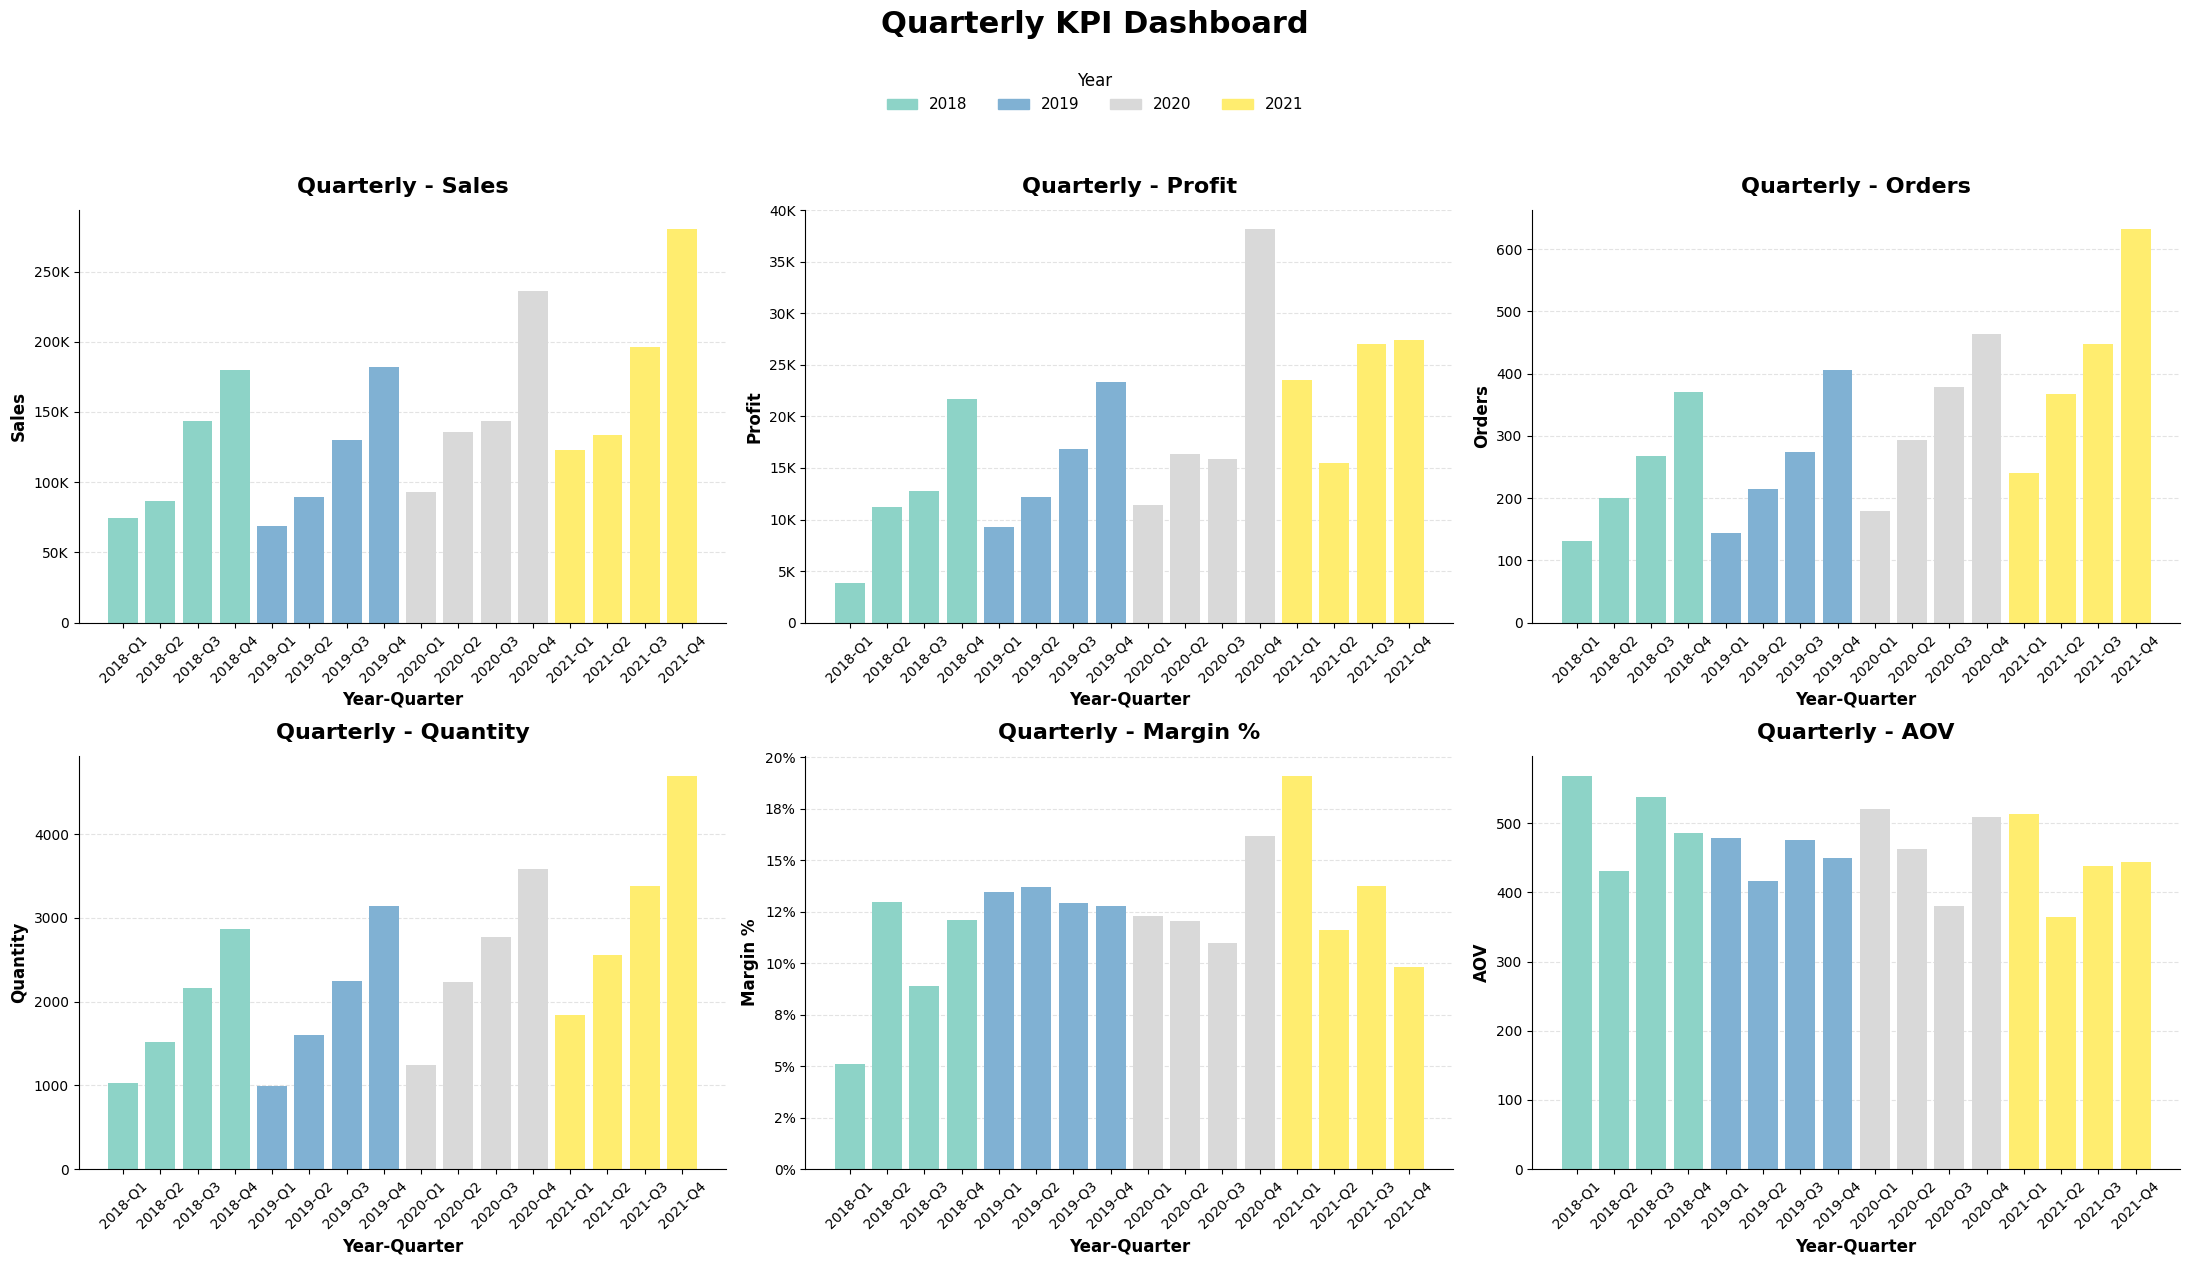

In [9]:
quarterly_plot = quarterly_kpi.copy()

quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
quarterly_plot['quarter_order'] = quarterly_plot['quarter'].map(quarter_order)

quarterly_plot = quarterly_plot.sort_values(['year', 'quarter_order']).reset_index(drop=True)
quarterly_plot['year_quarter'] = quarterly_plot['year'].astype(str) + '-' + quarterly_plot['quarter']


def money_fmt(x, pos):
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    if abs(x) >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

def pct_fmt(x, pos):
    return f'{x:.0f}%'

money_formatter = FuncFormatter(money_fmt)
pct_formatter = FuncFormatter(pct_fmt)

unique_years = sorted(quarterly_plot['year'].dropna().unique())
year_colors = dict(zip(unique_years, plt.cm.Set3(np.linspace(0, 1, len(unique_years)))))
bar_colors = quarterly_plot['year'].map(year_colors)

bar_charts = [
    ('sales', 'Quarterly - Sales', 'Sales'),
    ('profit', 'Quarterly - Profit', 'Profit'),
    ('orders', 'Quarterly - Orders', 'Orders'),
    ('quantity', 'Quarterly - Quantity', 'Quantity'),
    ('margin_pct', 'Quarterly - Margin %', 'Margin %'),
    ('aov', 'Quarterly - AOV', 'AOV')
]
line_charts = {}
all_charts = [('bar', *c) for c in bar_charts] + [('line', *c) for c in line_charts]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for ax, (chart_type, col, title, ylabel) in zip(axes, all_charts):
    if chart_type == 'bar':
        ax.bar(
            quarterly_plot['year_quarter'],
            quarterly_plot[col],
            color=bar_colors
        )
    else:
        ax.plot(
            quarterly_plot['year_quarter'],
            quarterly_plot[col],
            marker='o',
            linewidth=2.5
        )

    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel('Year-Quarter', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

    ax.tick_params(axis='x', labelrotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if col in ['sales', 'profit', 'aov']:
        ax.yaxis.set_major_formatter(money_formatter)
    elif col == 'margin_pct':
        ax.yaxis.set_major_formatter(pct_formatter)

    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[len(all_charts):]:
    ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=year_colors[yr], label=str(yr))
    for yr in unique_years
]
fig.legend(
    handles=handles,
    title='Year',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(unique_years),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

fig.suptitle('Quarterly KPI Dashboard', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

📊 Insight Quarterly

Secara umum, **Q4 selalu menjadi kuartal dengan performa penjualan tertinggi** sepanjang **2018–2021**. Pola ini terlihat konsisten pada **sales, orders, dan quantity**, sehingga Q4 bisa disebut sebagai **peak season utama** bisnis 🚀

Namun, tingginya penjualan di Q4 **tidak selalu diikuti oleh kenaikan AOV maupun margin**. Artinya, meskipun skala penjualan paling besar terjadi di akhir tahun, **kualitas pertumbuhannya belum tentu menjadi yang terbaik**.

🔎 Pola Utama
- **Q4 unggul dalam sales, orders, dan quantity**  
  → aktivitas penjualan paling ramai terjadi di kuartal akhir tahun.

- **Q4 tidak selalu unggul dari sisi profitabilitas**  
  → kenaikan sales sering kali lebih didorong oleh **volume penjualan**, bukan efisiensi margin.

📌 Khusus 2021
Pada **2021**, Q4 kembali mencatat **sales, orders, dan quantity tertinggi**. Namun, **profit tidak naik setajam sales**, yang menunjukkan bahwa pertumbuhan lebih banyak ditopang oleh **volume transaksi** daripada **profit per transaksi**.

Di sisi lain, **margin tertinggi pada 2021 justru terjadi di Q1**, lalu cenderung menurun di kuartal-kuartal berikutnya, termasuk saat masuk Q4.

## Category KPI

In [10]:
category_kpi = (
    df.groupby(category_col, as_index=False)
      .agg(
          sales=(sales_col, 'sum'),
          profit=(profit_col, 'sum'),
          orders=(order_id_col, 'nunique'),
          quantity=(quantity_col, 'sum'),
          discount=(discount_col, 'mean')
      )
)

category_kpi['margin_pct'] = (category_kpi['profit'] / category_kpi['sales']) * 100
category_kpi['aov'] = category_kpi['sales'] / category_kpi['orders']
category_kpi = category_kpi.sort_values(by='sales', ascending=False)

cols_to_round = ['sales', 'profit', 'discount', 'margin_pct', 'aov']
category_kpi[cols_to_round] = category_kpi[cols_to_round].round(2)

category_kpi

,Category,sales,profit,orders,quantity,discount,margin_pct,aov
2,Technology,836154.03,145454.95,1544,6939,0.13,17.40,541.55
0,Furniture,741999.80,18451.27,1764,8028,0.17,2.49,420.63
1,Office Supplies,719047.03,122490.80,3742,22906,0.16,17.04,192.16


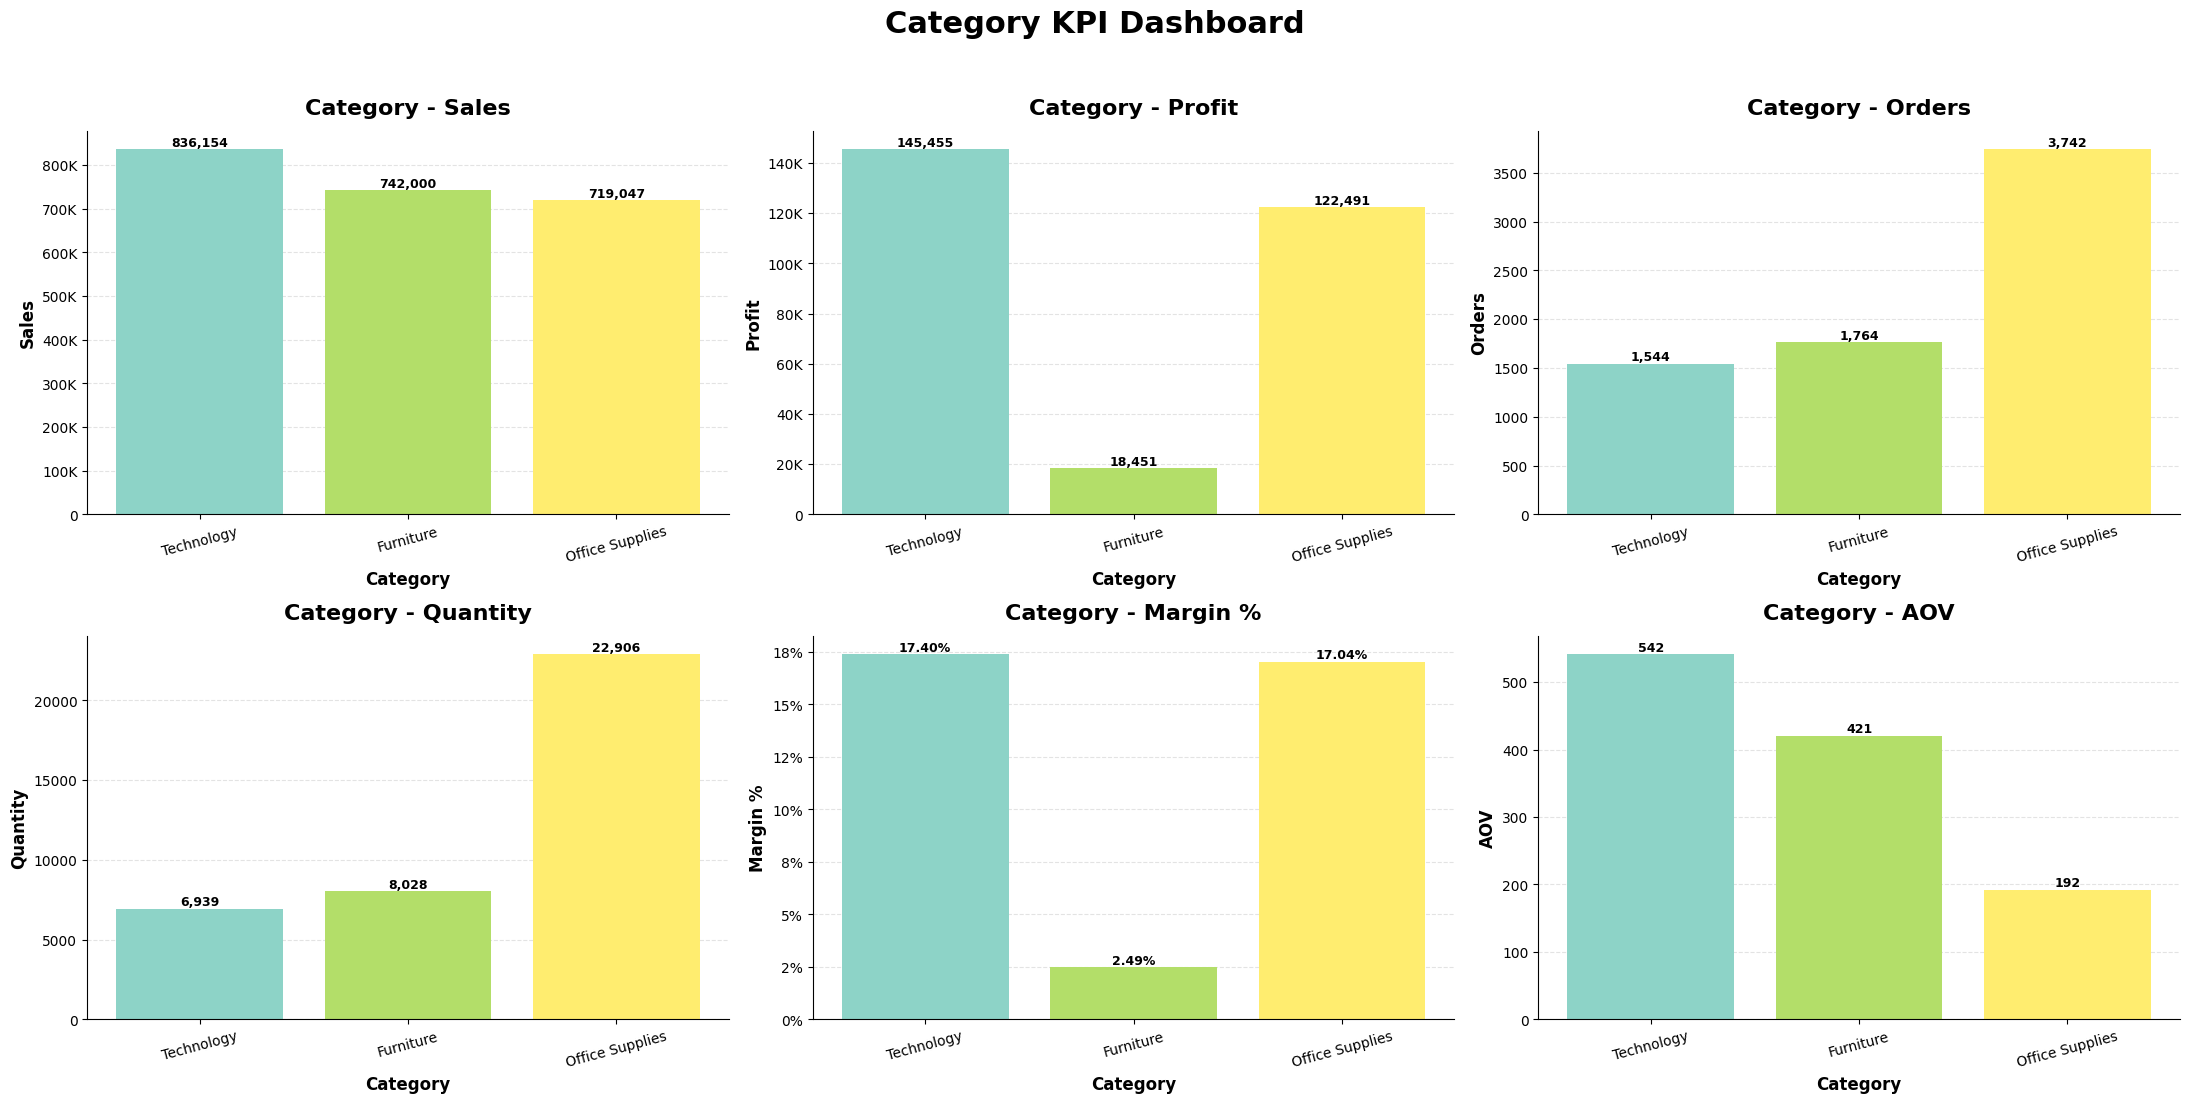

In [11]:
category_plot = category_kpi.copy()
category_plot = category_plot.sort_values('sales', ascending=False).reset_index(drop=True)

def money_fmt(x, pos):
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    if abs(x) >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

def pct_fmt(x, pos):
    return f'{x:.0f}%'

money_formatter = FuncFormatter(money_fmt)
pct_formatter = FuncFormatter(pct_fmt)

colors = plt.cm.Set3(np.linspace(0, 1, len(category_plot)))

charts = [
    ('sales', 'Category - Sales', 'Sales'),
    ('profit', 'Category - Profit', 'Profit'),
    ('orders', 'Category - Orders', 'Orders'),
    ('quantity', 'Category - Quantity', 'Quantity'),
    ('margin_pct', 'Category - Margin %', 'Margin %'),
    ('aov', 'Category - AOV', 'AOV'),
    # ('discount', 'Category - Avg Discount', 'Avg Discount')
]

fig, axes = plt.subplots(3, 3, figsize=(22, 15))
axes = axes.flatten()

for i, (col, title, ylabel) in enumerate(charts):
    ax = axes[i]
    bars = ax.bar(category_plot[category_col], category_plot[col], color=colors)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel('Category', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

    ax.tick_params(axis='x', labelrotation=15, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if col in ['sales', 'profit', 'aov']:
        ax.yaxis.set_major_formatter(money_formatter)
    elif col in ['margin_pct', 'discount']:
        ax.yaxis.set_major_formatter(pct_formatter)

    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar in bars:
        height = bar.get_height()

        if col in ['margin_pct', 'discount']:
            label = f'{height:.2f}%'
        elif col == 'quantity':
            label = f'{height:,.0f}'
        elif col == 'orders':
            label = f'{height:,.0f}'
        else:
            label = f'{height:,.0f}'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

for j in range(len(charts), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Category KPI Dashboard', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Category Per Tahun

In [12]:
category_year_kpi = (
    df.groupby(['year', category_col], as_index=False)
      .agg(
          sales=(sales_col, 'sum'),
          profit=(profit_col, 'sum'),
          orders=(order_id_col, 'nunique'),
          quantity=(quantity_col, 'sum'),
          discount=(discount_col, 'mean')
      )
)

category_year_kpi['margin_pct'] = (category_year_kpi['profit'] / category_year_kpi['sales']) * 100
category_year_kpi['aov'] = category_year_kpi['sales'] / category_year_kpi['orders']

cols_to_round = ['sales', 'profit', 'discount', 'margin_pct', 'aov']
category_year_kpi[cols_to_round] = category_year_kpi[cols_to_round].round(2)

category_year_kpi

,year,Category,sales,profit,orders,quantity,discount,margin_pct,aov
0,2018,Furniture,157192.85,5457.73,353,1623,0.18,3.47,445.31
1,2018,Office Supplies,151776.41,22593.42,746,4569,0.16,14.89,203.45
2,2018,Technology,175278.23,21492.83,291,1389,0.14,12.26,602.33
3,2019,Furniture,170518.24,3015.20,371,1775,0.17,1.77,459.62
4,2019,Office Supplies,137233.46,25099.53,778,4715,0.16,18.29,176.39
5,2019,Technology,162780.81,33503.87,338,1489,0.13,20.58,481.60
6,2020,Furniture,198901.44,6959.95,476,2193,0.18,3.50,417.86
7,2020,Office Supplies,183939.98,35061.23,946,5946,0.15,19.06,194.44
8,2020,Technology,226364.18,39773.99,389,1698,0.14,17.57,581.91
9,2021,Furniture,215387.27,3018.39,564,2437,0.17,1.40,381.89


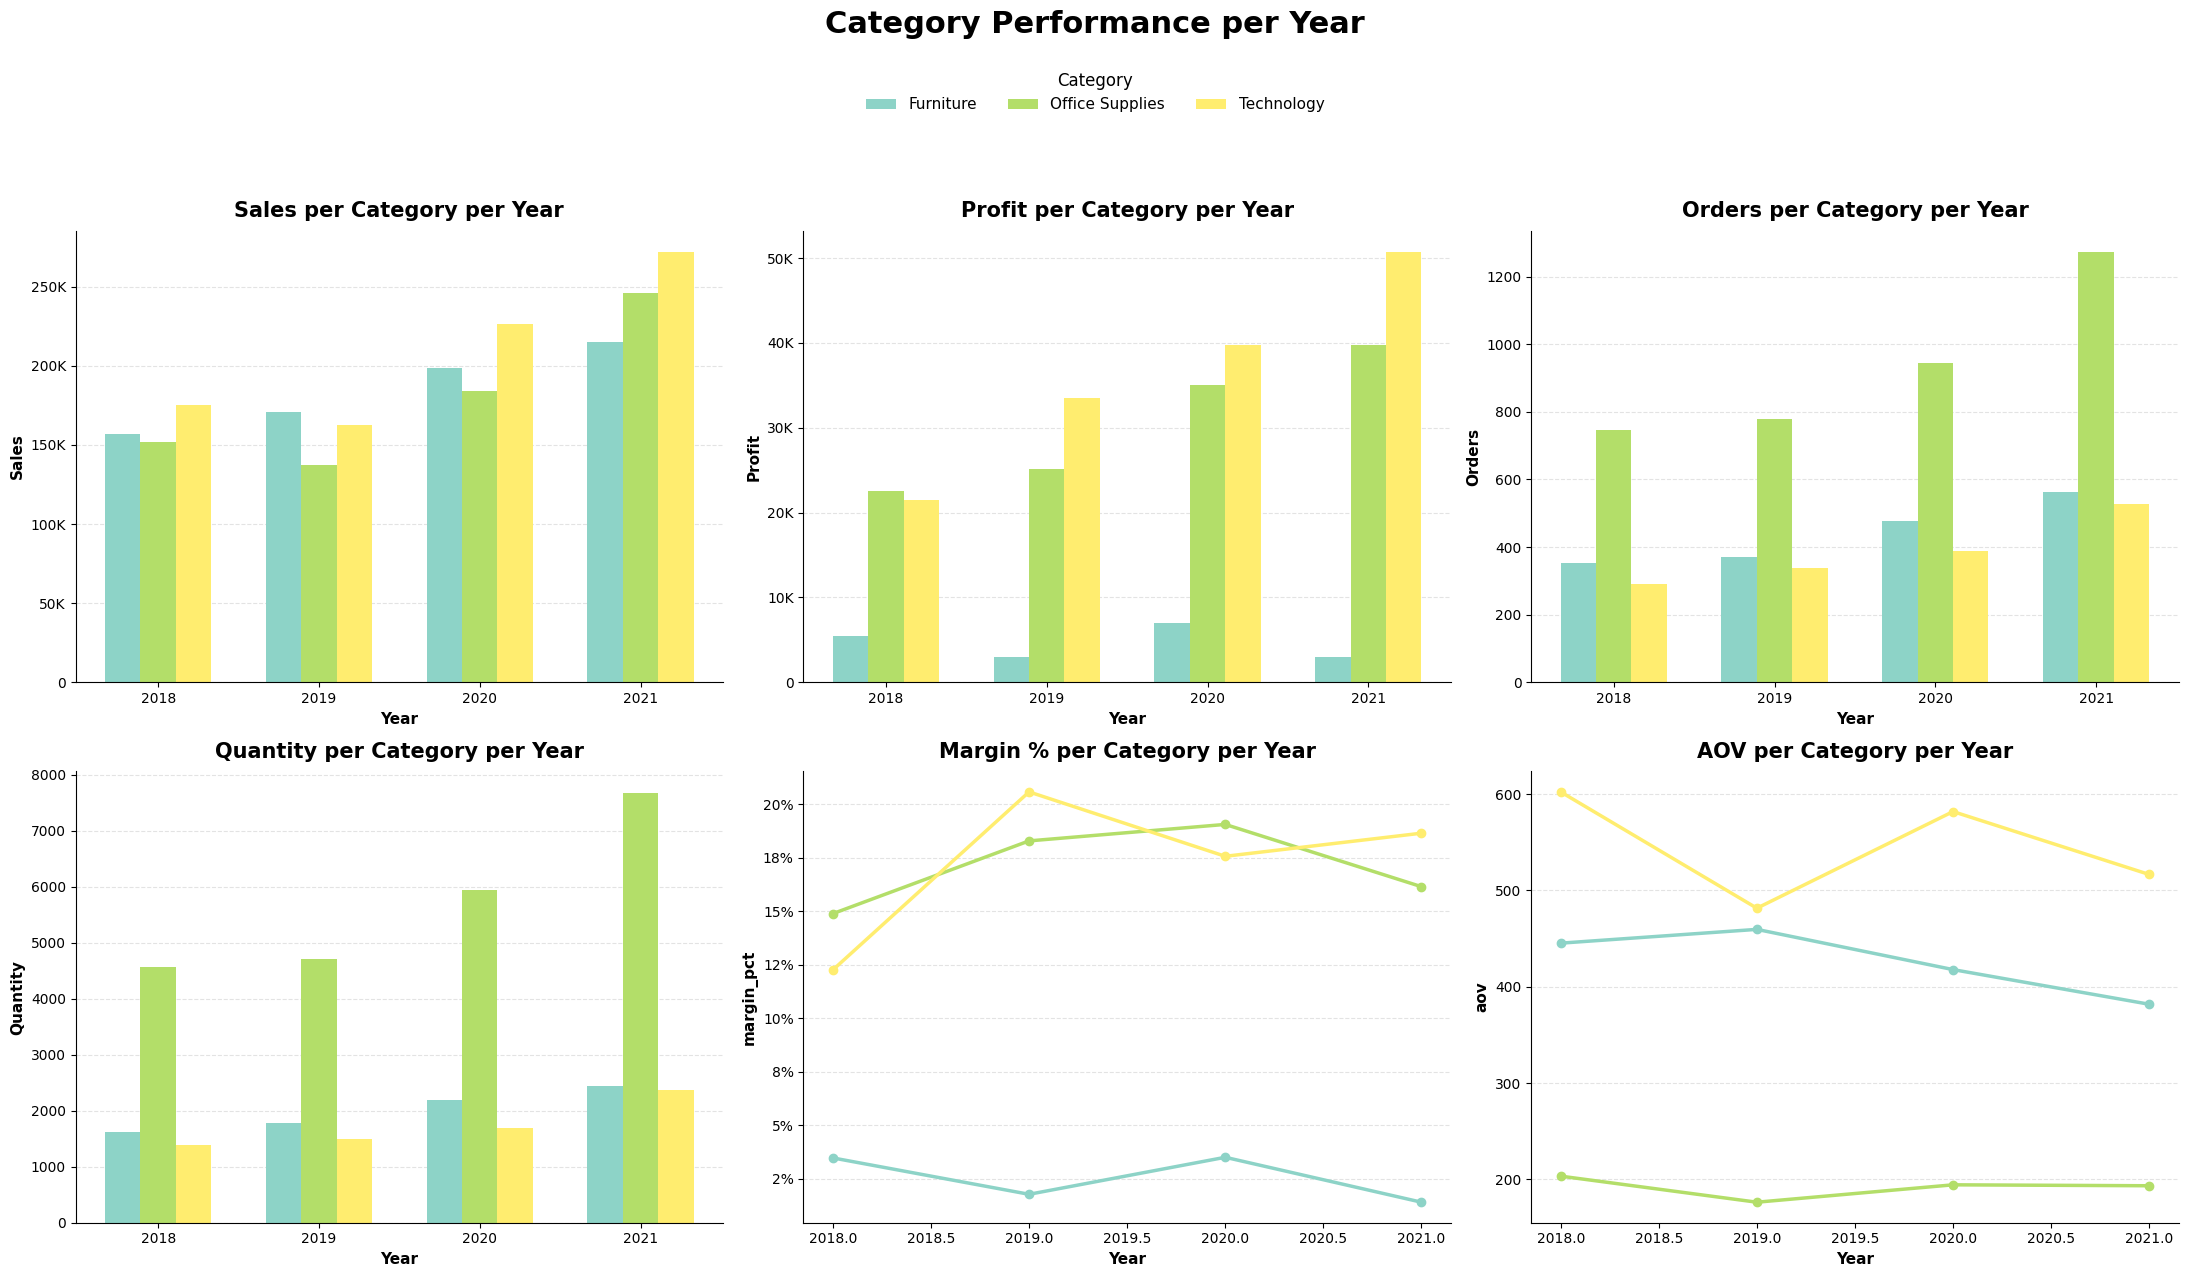

In [13]:
category_year_kpi = (
    df.groupby(['year', category_col], as_index=False)
      .agg(
          sales=(sales_col, 'sum'),
          profit=(profit_col, 'sum'),
          orders=(order_id_col, 'nunique'),
          quantity=(quantity_col, 'sum'),
          discount=(discount_col, 'mean')
      )
)

category_year_kpi['margin_pct'] = (category_year_kpi['profit'] / category_year_kpi['sales']) * 100
category_year_kpi['aov'] = category_year_kpi['sales'] / category_year_kpi['orders']

cols_to_round = ['sales', 'profit', 'discount', 'margin_pct', 'aov']
category_year_kpi[cols_to_round] = category_year_kpi[cols_to_round].round(2)

def money_fmt(x, pos):
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    if abs(x) >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

def pct_fmt(x, pos):
    return f'{x:.0f}%'

money_formatter = FuncFormatter(money_fmt)
pct_formatter = FuncFormatter(pct_fmt)

bar_metrics = ['sales', 'profit', 'orders', 'quantity']
line_metrics = ['margin_pct', 'aov']

all_metrics = bar_metrics + line_metrics

pivot_data = {
    m: category_year_kpi.pivot(index='year', columns=category_col, values=m).fillna(0).sort_index()
    for m in all_metrics
}

categories = pivot_data['sales'].columns.tolist()
years = pivot_data['sales'].index.astype(str)
x = np.arange(len(years))

colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

titles = {
    'sales': 'Sales per Category per Year',
    'profit': 'Profit per Category per Year',
    'orders': 'Orders per Category per Year',
    'quantity': 'Quantity per Category per Year',
    'margin_pct': 'Margin % per Category per Year',
    'aov': 'AOV per Category per Year'
}

for ax, metric in zip(axes[:4], bar_metrics):
    pivot_metric = pivot_data[metric]
    w = 0.22

    for i, cat in enumerate(categories):
        ax.bar(
            x + (i - (len(categories)-1)/2) * w,
            pivot_metric[cat].values,
            width=w,
            label=cat if metric == 'sales' else None,
            color=colors[i]
        )

    ax.set_title(titles[metric], fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric.capitalize(), fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(years)

    if metric in ['sales', 'profit']:
        ax.yaxis.set_major_formatter(money_formatter)

    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax, metric in zip(axes[4:], line_metrics):
    pivot_metric = pivot_data[metric]

    for i, cat in enumerate(categories):
        ax.plot(
            pivot_metric.index,
            pivot_metric[cat],
            marker='o',
            linewidth=2.5,
            label=cat if metric == 'margin_pct' else None,
            color=colors[i]
        )

    ax.set_title(titles[metric], fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')

    if metric == 'margin_pct':
        ax.yaxis.set_major_formatter(pct_formatter)
    elif metric == 'aov':
        ax.yaxis.set_major_formatter(money_formatter)

    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Category',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(categories),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

fig.suptitle('Category Performance per Year', fontsize=22, fontweight='bold', y=1.06)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

📊 Insight Category KPI Dashboard

Secara umum, performa kategori menunjukkan bahwa setiap category punya peran bisnis yang berbeda. **Technology** tampil sebagai kategori paling sehat karena unggul tidak hanya dari sisi **sales**, tetapi juga dari **profit, margin, dan AOV**. Ini menandakan bahwa Technology mampu menghasilkan omzet besar sekaligus mengonversinya menjadi profit secara efisien, sehingga layak diposisikan sebagai **profit driver** utama.

Di sisi lain, **Office Supplies** menjadi kategori dengan aktivitas transaksi paling tinggi. Orders dan quantity-nya paling besar, sementara sales dan profit tetap kuat. Namun, karena **AOV-nya paling rendah**, pertumbuhan kategori ini lebih banyak ditopang oleh **volume transaksi** daripada nilai per order. Artinya, Office Supplies berperan penting sebagai **volume driver** yang menjaga arus transaksi dan repeat order.

Sementara itu, **Furniture** menjadi kategori yang paling perlu mendapat perhatian. Walaupun sales-nya cukup besar dan AOV-nya juga relatif tinggi, profit yang dihasilkan sangat rendah dengan margin yang paling lemah. Ini menunjukkan bahwa masalah utama Furniture bukan pada demand, melainkan pada kemampuannya mengubah penjualan menjadi profit. Dengan kata lain, Furniture adalah kategori yang **besar secara omzet, tetapi lemah secara profitabilitas**.

🔎 Kesimpulan Utama
- **Technology** = kategori paling sehat dan paling kuat sebagai pendorong profit  
- **Office Supplies** = kategori utama untuk menjaga volume transaksi  
- **Furniture** = kategori yang perlu evaluasi karena sales tinggi tetapi profit sangat tipis  

# Rekomendasi Strategis Bisnis

Berdasarkan pola performa penjualan, profitabilitas kategori, serta dinamika pertumbuhan transaksi, berikut beberapa rekomendasi strategis yang dapat diprioritaskan perusahaan:

---

1.  Jadikan Technology bukan hanya profit driver, tetapi juga alat positioning brand

Saat ini kategori **Technology** terlihat sebagai kategori paling sehat dari sisi bisnis karena unggul dalam sales, profit, margin, dan AOV. Posisi ini menunjukkan bahwa Technology bukan hanya menghasilkan profit, tetapi juga punya potensi besar untuk membentuk persepsi pasar terhadap brand.

Perusahaan sebaiknya menjadikan kategori Technology sebagai **alat positioning**, bukan hanya sumber keuntungan. Caranya adalah dengan membangun citra bahwa toko/brand memiliki produk teknologi yang **kompetitif, terpercaya, dan layak dijadikan referensi utama** oleh customer.

Salah satu pendekatan yang dapat diterapkan adalah **trust-building pricing**, yaitu strategi harga yang tidak selalu paling murah, tetapi cukup kompetitif untuk membangun kepercayaan bahwa toko menawarkan harga yang fair, transparan, dan masuk akal. Ketika customer melihat bahwa produk Technology dijual dengan harga yang kredibel dan konsisten, kepercayaan terhadap brand secara keseluruhan akan meningkat.

Dengan demikian, peningkatan penjualan Technology tidak hanya berdampak pada profit, tetapi juga pada reputasi toko sebagai penyedia kebutuhan kerja yang lebih profesional dan terpercaya.

**Arah aksi:**
- tetapkan pricing Technology yang kompetitif dan konsisten,
- prioritaskan ketersediaan stok pada produk Technology unggulan,
- tampilkan kategori Technology sebagai kategori andalan,
- gunakan produk Technology untuk memperkuat citra toko yang profesional dan dapat dipercaya.

**Dampak yang diharapkan:**
- brand credibility meningkat,
- customer lebih percaya untuk melakukan pembelian bernilai tinggi,
- Technology menjadi anchor category untuk membangun reputasi,
- dan profit bertumbuh bersamaan dengan penguatan positioning brand.

---

2. Lakukan audit menyeluruh pada Furniture, revisi harga, dan kembangkan model solution B2B

Kategori **Furniture** menunjukkan sinyal bahwa sales masih besar, tetapi profitabilitasnya lemah. Ini berarti permasalahan utama kemungkinan bukan pada demand, melainkan pada struktur biaya, pricing, diskon, atau komposisi produk.

Karena itu, perusahaan perlu melakukan **audit total terhadap kategori Furniture** untuk mengidentifikasi sumber kebocoran margin. Audit ini penting agar perusahaan tidak terus mempertahankan penjualan besar yang sebenarnya tidak memberikan kontribusi profit yang memadai.

Selain audit dan revisi harga, perusahaan juga perlu mempertimbangkan pendekatan yang lebih strategis, yaitu mengembangkan **model solution B2B**. Artinya, Furniture tidak hanya dijual sebagai produk satuan, tetapi sebagai bagian dari solusi kebutuhan workspace untuk kantor atau UMKM, misalnya:

- paket meja kerja,
- setup workstation sederhana,
- paket furniture untuk kantor kecil,
- atau solusi ruang kerja yang dikombinasikan dengan kategori lain.

Pendekatan ini berpotensi meningkatkan nilai transaksi, memperjelas value proposition, dan mengurangi ketergantungan pada penjualan item individual yang marginnya tipis.

**Arah aksi:**
- audit sub-category dan SKU Furniture yang paling lemah profitnya,
- evaluasi tingkat diskon, biaya logistik, dan struktur harga,
- revisi pricing pada produk yang selama ini besar omzet tetapi lemah margin,
- bangun penawaran berbasis solusi untuk segmen kantor dan UMKM.

**Dampak yang diharapkan:**
- margin Furniture menjadi lebih sehat,
- kategori tidak lagi hanya besar di omzet tetapi lemah di profit,
- average deal size berpotensi meningkat,
- dan Furniture bisa diubah dari kategori bermasalah menjadi kategori solusi.

---

3. Bangun customer migration path untuk menaikkan value customer secara bertahap

Salah satu tantangan utama bisnis adalah bagaimana mengubah pembelian dengan nilai kecil dan rutin menjadi pembelian dengan nilai lebih tinggi dan profitabilitas yang lebih baik. Karena itu, perusahaan tidak cukup hanya menjual banyak produk, tetapi perlu **membangun jalur migrasi customer**.

Customer migration path berarti perusahaan secara sengaja merancang perpindahan customer dari pembelian sederhana ke pembelian yang lebih bernilai. Misalnya, customer yang awalnya membeli kebutuhan Office Supplies diarahkan secara bertahap ke:

- office accessories,
- workspace tools,
- produk Technology,
- hingga kebutuhan workspace yang lebih lengkap.

Dengan pendekatan ini, customer tidak berhenti pada transaksi kecil berulang, melainkan berkembang menjadi customer dengan kontribusi revenue dan profit yang lebih besar.

Strategi ini dapat dilakukan melalui:
- bundling produk,
- cross-sell antar kategori,
- promo bertahap,
- rekomendasi produk pelengkap,
- dan campaign berdasarkan histori belanja.

**Arah aksi:**
- petakan produk jembatan antar kategori,
- buat bundling yang mendorong customer naik kelas,
- gunakan rekomendasi produk yang relevan setelah pembelian,
- rancang promo yang tidak hanya mengejar volume, tetapi juga mendorong perpindahan ke kategori bernilai lebih tinggi.

**Dampak yang diharapkan:**
- AOV meningkat secara lebih natural,
- customer lifetime value bertumbuh,
- profit tumbuh dari customer yang sama,
- dan bisnis tidak hanya bergantung pada order kecil berulang.

---

4. Perluas positioning toko: dari sekadar penjual menjadi Procurement Concierge untuk kantor dan UMKM

Agar bisnis memiliki diferensiasi yang lebih kuat, perusahaan perlu mulai membangun positioning yang lebih tinggi dari sekadar toko yang menjual produk. Arah yang lebih strategis adalah menjadikan brand sebagai **Procurement Concierge** untuk kantor dan UMKM.

Maknanya, perusahaan tidak hanya berperan sebagai penjual barang, tetapi sebagai partner yang membantu customer memenuhi kebutuhan operasional mereka secara lebih praktis, relevan, dan terpercaya. Dengan positioning ini, perusahaan menawarkan kemudahan, kurasi produk, rekomendasi solusi, dan pengalaman belanja yang lebih terarah.

Pendekatan ini akan sangat relevan terutama jika perusahaan memiliki kekuatan di beberapa kategori yang saling mendukung, seperti Office Supplies, Technology, dan Furniture. Ketiganya bisa disatukan dalam narasi yang lebih besar: membantu kantor dan UMKM memenuhi kebutuhan kerja mereka dari kebutuhan rutin hingga kebutuhan setup workspace.

**Arah aksi:**
- bangun komunikasi brand yang menekankan peran sebagai partner procurement,
- susun katalog dan penawaran berdasarkan kebutuhan bisnis customer, bukan hanya berdasarkan kategori produk,
- hadirkan bundling atau paket solusi untuk kantor kecil dan UMKM,
- perkuat layanan konsultatif, rekomendasi, dan kemudahan repeat order.

**Dampak yang diharapkan:**
- brand memiliki positioning yang lebih kuat dan berbeda,
- customer lebih loyal karena merasa dibantu, bukan sekadar dilayani,
- peluang cross-category menjadi lebih besar,
- dan bisnis lebih mudah masuk ke kebutuhan pembelian yang bernilai lebih tinggi.

---

# Kesimpulan Strategis

Secara keseluruhan, arah pengembangan bisnis sebaiknya tidak hanya berfokus pada mendorong penjualan jangka pendek, tetapi juga membangun fondasi pertumbuhan yang lebih sehat dan berkelanjutan. Perusahaan perlu:

- membangun basis customer lebih awal sebelum Q4,
- menggunakan Technology sebagai profit engine sekaligus alat pembentuk kepercayaan brand,
- membenahi Furniture agar tidak terus menjadi sumber kebocoran margin,
- mendorong customer naik kelas melalui migration path,
- dan memperluas positioning toko menjadi partner procurement untuk kantor dan UMKM.

Dengan pendekatan ini, pertumbuhan bisnis tidak hanya akan lebih besar dari sisi volume, tetapi juga lebih kuat dari sisi kualitas profit, loyalitas customer, dan posisi brand di pasar.